In [1]:
# import required libraries
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
python_path = sys.executable
spark = (
    SparkSession.builder
    .appName("bus_route_recovery_priority")
    .config("spark.sql.shuffle.partitions","4")
    .config("spark.sql.session.timeZone","Europe/London")
    .config("spark.pyspark.python",python_path)
    .config("spark.pyspark.driver.python",python_path)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("spark session created")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/17 21:45:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/17 21:45:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


spark session created


In [2]:
# define project folders
current_folder = Path.cwd()
if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder
prediction_input_path = (
    project_root
    / "data"
    / "processed"
    / "model_predictions"
    / "best_model_predictions"
)
model_feature_input_path = (
    project_root
    / "data"
    / "processed"
    / "disruption_modelling_data_csv"
)
priority_output_path = (
    project_root
    / "data"
    / "processed"
    / "recovery_priority"
)
priority_visualization_path = (
    project_root
    / "visualizations"
    / "recovery_priority"
)
priority_output_path.mkdir(parents=True,exist_ok=True)
priority_visualization_path.mkdir(parents=True,exist_ok=True)
print("project root:",project_root)
print("prediction input exists:",prediction_input_path.exists())
print("model feature input exists:",model_feature_input_path.exists())
print("priority output folder:",priority_output_path)
print("priority visualization folder:",priority_visualization_path)
if not prediction_input_path.exists():
    raise FileNotFoundError("best model prediction folder was not found")
if not model_feature_input_path.exists():
    raise FileNotFoundError("modelling feature folder was not found")

project root: /Users/babitaadhikari/Desktop/bus-disruption-platform
prediction input exists: True
model feature input exists: True
priority output folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority
priority visualization folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority


In [3]:
# load best model predictions
predictions_df = (
    spark.read
    .option("header",True)
    .option("inferSchema",True)
    .csv(str(prediction_input_path))
)
predictions_df = (
    predictions_df
    .repartition(4,"line_ref")
    .cache()
)
prediction_rows = predictions_df.count()
print("prediction rows:",f"{prediction_rows:,}")
print("prediction columns:",len(predictions_df.columns))
print("prediction partitions:",predictions_df.rdd.getNumPartitions())
predictions_df.printSchema()

prediction rows: 1,153
prediction columns: 10
prediction partitions: 4
root
 |-- event_snapshot_time: timestamp (nullable = true)
 |-- next_snapshot_time: timestamp (nullable = true)
 |-- line_ref: string (nullable = true)
 |-- published_line_name: string (nullable = true)
 |-- direction_ref: string (nullable = true)
 |-- actual_severity: string (nullable = true)
 |-- predicted_severity: string (nullable = true)
 |-- label: double (nullable = true)
 |-- prediction: double (nullable = true)
 |-- probability_text: string (nullable = true)



In [4]:
# load operational feature data
model_feature_df = (
    spark.read
    .option("header",True)
    .option("inferSchema",True)
    .csv(str(model_feature_input_path))
)
model_feature_df = (
    model_feature_df
    .repartition(4,"line_ref")
    .cache()
)
model_feature_rows = model_feature_df.count()
print("model feature rows:",f"{model_feature_rows:,}")
print("model feature columns:",len(model_feature_df.columns))
print("model feature partitions:",model_feature_df.rdd.getNumPartitions())

26/07/17 21:45:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 12:>                                                         (0 + 4) / 4]

model feature rows: 7,962
model feature columns: 47
model feature partitions: 4


In [5]:
# define required prediction columns
required_prediction_columns = [
    "event_snapshot_time",
    "next_snapshot_time",
    "line_ref",
    "published_line_name",
    "direction_ref",
    "actual_severity",
    "predicted_severity",
    "label",
    "prediction",
    "probability_text"
]
# define required operational columns
required_feature_columns = [
    "event_snapshot_time",
    "next_snapshot_time",
    "line_ref",
    "direction_ref",
    "observation_hour",
    "is_peak_hour",
    "observed_vehicle_count",
    "observed_journey_count",
    "exact_match_rate",
    "fallback_match_rate",
    "activity_ratio",
    "spacing_ratio",
    "activity_shortfall",
    "spacing_excess",
    "previous_vehicle_drop"
]
missing_prediction_columns = [
    column_name
    for column_name in required_prediction_columns
    if column_name not in predictions_df.columns
]
missing_feature_columns = [
    column_name
    for column_name in required_feature_columns
    if column_name not in model_feature_df.columns
]
print("missing prediction columns:",missing_prediction_columns)
print("missing feature columns:",missing_feature_columns)
if missing_prediction_columns:
    raise ValueError("required prediction columns are missing")
if missing_feature_columns:
    raise ValueError("required operational feature columns are missing")

missing prediction columns: []
missing feature columns: []


In [6]:
# convert timestamps into a consistent type
predictions_df = (
    predictions_df
    .withColumn("event_snapshot_time",F.to_timestamp("event_snapshot_time"))
    .withColumn("next_snapshot_time",F.to_timestamp("next_snapshot_time"))
)
# split the saved probability vector
probability_array = F.split(
    F.regexp_replace(
        F.col("probability_text"),
        r"[\[\]]",
        ""
    ),
    ","
)
predictions_df = (
    predictions_df
    .withColumn("low_probability",F.trim(F.element_at(probability_array,1)).cast("double"))
    .withColumn("medium_probability",F.trim(F.element_at(probability_array,2)).cast("double"))
    .withColumn("high_probability",F.trim(F.element_at(probability_array,3)).cast("double"))
    .withColumn(
        "probability_sum",
        F.round(
            F.col("low_probability")
            + F.col("medium_probability")
            + F.col("high_probability"),
            4
        )
    )
)
invalid_probability_rows = (
    predictions_df
    .filter(
        F.col("low_probability").isNull()
        | F.col("medium_probability").isNull()
        | F.col("high_probability").isNull()
        | (F.abs(F.col("probability_sum") - F.lit(1.0)) > F.lit(0.01))
    )
    .count()
)
print("invalid probability rows:",invalid_probability_rows)
predictions_df.select(
    "predicted_severity",
    "low_probability",
    "medium_probability",
    "high_probability",
    "probability_sum"
).show(
    10,
    truncate=False
)
if invalid_probability_rows > 0:
    raise ValueError("some prediction probabilities are invalid")

invalid probability rows: 0
+------------------+-------------------+--------------------+--------------------+---------------+
|predicted_severity|low_probability    |medium_probability  |high_probability    |probability_sum|
+------------------+-------------------+--------------------+--------------------+---------------+
|high              |0.1919713461007229 |0.34387358261591955 |0.4641550712833575  |1.0            |
|low               |0.9687064631547605 |0.015462636423166485|0.015830900422073024|1.0            |
|high              |0.4476647889927565 |0.03185775483333711 |0.5204774561739063  |1.0            |
|low               |0.9695160974502369 |0.005607262820937111|0.024876639728825964|1.0            |
|medium            |0.2282413094134575 |0.6189045758954776  |0.15285411469106494 |1.0            |
|medium            |0.27386706830233654|0.4165747707504109  |0.30955816094725264 |1.0            |
|low               |0.46835905444022996|0.1327741118126641  |0.39886683374710585 

In [7]:
# define columns used to join predictions and features
join_columns = [
    "event_snapshot_time",
    "next_snapshot_time",
    "line_ref",
    "direction_ref"
]
# prepare operational feature columns
recovery_feature_columns = join_columns + [
    "observation_hour",
    "is_peak_hour",
    "observed_vehicle_count",
    "observed_journey_count",
    "exact_match_rate",
    "fallback_match_rate",
    "activity_ratio",
    "spacing_ratio",
    "activity_shortfall",
    "spacing_excess",
    "previous_vehicle_drop"
]
recovery_feature_df = (
    model_feature_df
    .select(*recovery_feature_columns)
    .withColumn("event_snapshot_time",F.to_timestamp("event_snapshot_time"))
    .withColumn("next_snapshot_time",F.to_timestamp("next_snapshot_time"))
    .dropDuplicates(join_columns)
    .cache()
)
recovery_feature_rows = recovery_feature_df.count()
print("unique recovery feature rows:",f"{recovery_feature_rows:,}")

[Stage 28:>                                                         (0 + 4) / 4]

unique recovery feature rows: 7,063


In [8]:
# join predictions with operational feature data
priority_base_df = (
    predictions_df
    .join(
        recovery_feature_df,
        on=join_columns,
        how="left"
    )
    .cache()
)
priority_base_rows = priority_base_df.count()
unmatched_feature_rows = (
    priority_base_df
    .filter(F.col("activity_shortfall").isNull())
    .count()
)
print("joined priority rows:",f"{priority_base_rows:,}")
print("unmatched feature rows:",unmatched_feature_rows)
if priority_base_rows != prediction_rows:
    raise ValueError("prediction row count changed after joining")
# fill operational values only when a feature row did not match
operational_fill_values = {
    "observation_hour":0,
    "is_peak_hour":0,
    "observed_vehicle_count":0.0,
    "observed_journey_count":0.0,
    "exact_match_rate":0.0,
    "fallback_match_rate":0.0,
    "activity_ratio":0.0,
    "spacing_ratio":0.0,
    "activity_shortfall":0.0,
    "spacing_excess":0.0,
    "previous_vehicle_drop":0.0
}
priority_base_df = (
    priority_base_df
    .withColumn(
        "feature_join_status",
        F.when(
            F.col("activity_shortfall").isNull(),
            "unmatched"
        ).otherwise("matched")
    )
    .fillna(operational_fill_values)
    .cache()
)
print("feature join status")
priority_base_df.groupBy("feature_join_status").count().show()

joined priority rows: 1,153
unmatched feature rows: 0
feature join status
+-------------------+-----+
|feature_join_status|count|
+-------------------+-----+
|            matched| 1153|
+-------------------+-----+



In [9]:
# limit operational risk values between zero and one
priority_df = (
    priority_base_df
    .withColumn(
        "predicted_risk_probability",
        F.round(
            F.col("high_probability")
            + F.lit(0.5) * F.col("medium_probability"),
            4
        )
    )
    .withColumn(
        "activity_risk",
        F.least(
            F.greatest(F.col("activity_shortfall"),F.lit(0.0)),
            F.lit(1.0)
        )
    )
    .withColumn(
        "spacing_risk",
        F.least(
            F.greatest(F.col("spacing_excess"),F.lit(0.0)),
            F.lit(1.0)
        )
    )
    .withColumn(
        "vehicle_drop_risk",
        F.least(
            F.greatest(F.col("previous_vehicle_drop"),F.lit(0.0)),
            F.lit(1.0)
        )
    )
    .withColumn(
        "peak_hour_risk",
        F.when(
            F.col("is_peak_hour") == 1,
            F.lit(1.0)
        ).otherwise(F.lit(0.0))
    )
)
# calculate recovery priority score
priority_df = (
    priority_df
    .withColumn(
        "recovery_priority_score",
        F.round(
            F.lit(100.0) * (
                F.lit(0.50) * F.col("predicted_risk_probability")
                + F.lit(0.20) * F.col("activity_risk")
                + F.lit(0.15) * F.col("spacing_risk")
                + F.lit(0.10) * F.col("vehicle_drop_risk")
                + F.lit(0.05) * F.col("peak_hour_risk")
            ),
            2
        )
    )
    .withColumn(
        "recovery_priority_level",
        F.when(
            F.col("recovery_priority_score") >= 70,
            "critical"
        ).when(
            F.col("recovery_priority_score") >= 50,
            "high"
        ).when(
            F.col("recovery_priority_score") >= 30,
            "medium"
        ).otherwise("low")
    )
    .withColumn(
        "priority_order",
        F.when(F.col("recovery_priority_level") == "critical",4)
        .when(F.col("recovery_priority_level") == "high",3)
        .when(F.col("recovery_priority_level") == "medium",2)
        .otherwise(1)
    )
    .withColumn(
        "recommended_recovery_action",
        F.when(
            F.col("recovery_priority_level") == "critical",
            "dispatch additional vehicle and review immediately"
        ).when(
            F.col("recovery_priority_level") == "high",
            "adjust vehicle allocation and monitor next snapshot"
        ).when(
            F.col("recovery_priority_level") == "medium",
            "monitor route and prepare recovery support"
        ).otherwise(
            "continue normal monitoring"
        )
    )
    .cache()
)
priority_rows = priority_df.count()
print("priority rows:",f"{priority_rows:,}")
priority_df.select(
    "line_ref",
    "published_line_name",
    "direction_ref",
    "predicted_severity",
    "predicted_risk_probability",
    "recovery_priority_score",
    "recovery_priority_level",
    "recommended_recovery_action"
).orderBy(
    F.desc("recovery_priority_score")
).show(
    20,
    truncate=False
)

priority rows: 1,153
+--------+-------------------+-------------+------------------+--------------------------+-----------------------+-----------------------+---------------------------------------------------+
|line_ref|published_line_name|direction_ref|predicted_severity|predicted_risk_probability|recovery_priority_score|recovery_priority_level|recommended_recovery_action                        |
+--------+-------------------+-------------+------------------+--------------------------+-----------------------+-----------------------+---------------------------------------------------+
|6       |6                  |outbound     |high              |0.9013                    |65.07                  |high                   |adjust vehicle allocation and monitor next snapshot|
|50      |50                 |outbound     |high              |0.7348                    |64.69                  |high                   |adjust vehicle allocation and monitor next snapshot|
|22      |22            

In [10]:
# display predicted severity distribution
print("predicted severity distribution")
priority_df.groupBy(
    "predicted_severity"
).count().orderBy(
    F.desc("count")
).show()
# display recovery priority distribution
print("recovery priority distribution")
priority_df.groupBy(
    "priority_order",
    "recovery_priority_level"
).count().orderBy(
    F.desc("priority_order")
).show()
# display recommended action distribution
print("recommended recovery action distribution")
priority_df.groupBy(
    "recommended_recovery_action"
).count().orderBy(
    F.desc("count")
).show()
# display priority score statistics
priority_df.select(
    F.min("recovery_priority_score").alias("minimum_priority_score"),
    F.round(F.avg("recovery_priority_score"),2).alias("average_priority_score"),
    F.max("recovery_priority_score").alias("maximum_priority_score")
).show()

predicted severity distribution
+------------------+-----+
|predicted_severity|count|
+------------------+-----+
|               low|  669|
|            medium|  289|
|              high|  195|
+------------------+-----+

recovery priority distribution
+--------------+-----------------------+-----+
|priority_order|recovery_priority_level|count|
+--------------+-----------------------+-----+
|             3|                   high|   47|
|             2|                 medium|  348|
|             1|                    low|  758|
+--------------+-----------------------+-----+

recommended recovery action distribution
+---------------------------+-----+
|recommended_recovery_action|count|
+---------------------------+-----+
|       continue normal m...|  758|
|       monitor route and...|  348|
|       adjust vehicle al...|   47|
+---------------------------+-----+

+----------------------+----------------------+----------------------+
|minimum_priority_score|average_priority_score|maxim

In [11]:
# create route and direction summary
route_recovery_summary_df = (
    priority_df
    .groupBy(
        "line_ref",
        "published_line_name",
        "direction_ref"
    )
    .agg(
        F.count("*").alias("total_observations"),
        F.round(F.avg("recovery_priority_score"),2).alias("average_priority_score"),
        F.round(F.max("recovery_priority_score"),2).alias("maximum_priority_score"),
        F.round(F.avg("predicted_risk_probability"),4).alias("average_predicted_risk"),
        F.sum(
            F.when(
                F.col("recovery_priority_level") == "critical",
                1
            ).otherwise(0)
        ).alias("critical_observation_count"),
        F.sum(
            F.when(
                F.col("recovery_priority_level") == "high",
                1
            ).otherwise(0)
        ).alias("high_observation_count"),
        F.sum(
            F.when(
                F.col("predicted_severity") == "high",
                1
            ).otherwise(0)
        ).alias("predicted_high_severity_count")
    )
    .withColumn(
        "urgent_observation_count",
        F.col("critical_observation_count")
        + F.col("high_observation_count")
    )
)
# rank route summaries
route_rank_window = Window.orderBy(
    F.desc("urgent_observation_count"),
    F.desc("maximum_priority_score"),
    F.desc("average_priority_score"),
    F.asc("line_ref")
)
route_recovery_summary_df = (
    route_recovery_summary_df
    .withColumn(
        "route_recovery_rank",
        F.dense_rank().over(route_rank_window)
    )
    .orderBy(
        "route_recovery_rank",
        "line_ref",
        "direction_ref"
    )
    .cache()
)
route_summary_rows = route_recovery_summary_df.count()
print("route summary rows:",f"{route_summary_rows:,}")
route_recovery_summary_df.show(
    20,
    truncate=False
)

26/07/17 21:48:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 2

route summary rows: 244
+--------+-------------------+-------------+------------------+----------------------+----------------------+----------------------+--------------------------+----------------------+-----------------------------+------------------------+-------------------+
|line_ref|published_line_name|direction_ref|total_observations|average_priority_score|maximum_priority_score|average_predicted_risk|critical_observation_count|high_observation_count|predicted_high_severity_count|urgent_observation_count|route_recovery_rank|
+--------+-------------------+-------------+------------------+----------------------+----------------------+----------------------+--------------------------+----------------------+-----------------------------+------------------------+-------------------+
|18      |18                 |outbound     |19                |36.18                 |59.47                 |0.5071                |0                         |4                     |10                  

26/07/17 21:48:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [12]:
# find the latest observation for each route and direction
latest_route_window = Window.partitionBy(
    "line_ref",
    "direction_ref"
).orderBy(
    F.desc("event_snapshot_time"),
    F.desc("next_snapshot_time")
)
latest_route_priority_df = (
    priority_df
    .withColumn(
        "latest_route_row",
        F.row_number().over(latest_route_window)
    )
    .filter(F.col("latest_route_row") == 1)
    .drop("latest_route_row")
)
# rank the latest route priorities
latest_rank_window = Window.orderBy(
    F.desc("priority_order"),
    F.desc("recovery_priority_score"),
    F.desc("predicted_risk_probability"),
    F.asc("line_ref")
)
latest_route_ranking_df = (
    latest_route_priority_df
    .withColumn(
        "latest_recovery_rank",
        F.dense_rank().over(latest_rank_window)
    )
    .orderBy(
        "latest_recovery_rank",
        "line_ref",
        "direction_ref"
    )
    .cache()
)
latest_route_rows = latest_route_ranking_df.count()
print("latest route ranking rows:",f"{latest_route_rows:,}")
latest_route_ranking_df.select(
    "latest_recovery_rank",
    "event_snapshot_time",
    "line_ref",
    "published_line_name",
    "direction_ref",
    "predicted_severity",
    "predicted_risk_probability",
    "recovery_priority_score",
    "recovery_priority_level",
    "recommended_recovery_action"
).show(
    20,
    truncate=False
)

26/07/17 21:48:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 2

latest route ranking rows: 244


26/07/17 21:48:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+--------------------+-----------------------+--------+-------------------+-------------+------------------+--------------------------+-----------------------+-----------------------+---------------------------------------------------+
|latest_recovery_rank|event_snapshot_time    |line_ref|published_line_name|direction_ref|predicted_severity|predicted_risk_probability|recovery_priority_score|recovery_priority_level|recommended_recovery_action                        |
+--------------------+-----------------------+--------+-------------------+-------------+------------------+--------------------------+-----------------------+-----------------------+---------------------------------------------------+
|1                   |2026-07-16 10:52:51.52 |15      |15                 |inbound      |high              |0.9405                    |62.03                  |high                   |adjust vehicle allocation and monitor next snapshot|
|2                   |2026-07-16 10:22:46.381|60      |6

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/01_predicted_severity_distribution.png


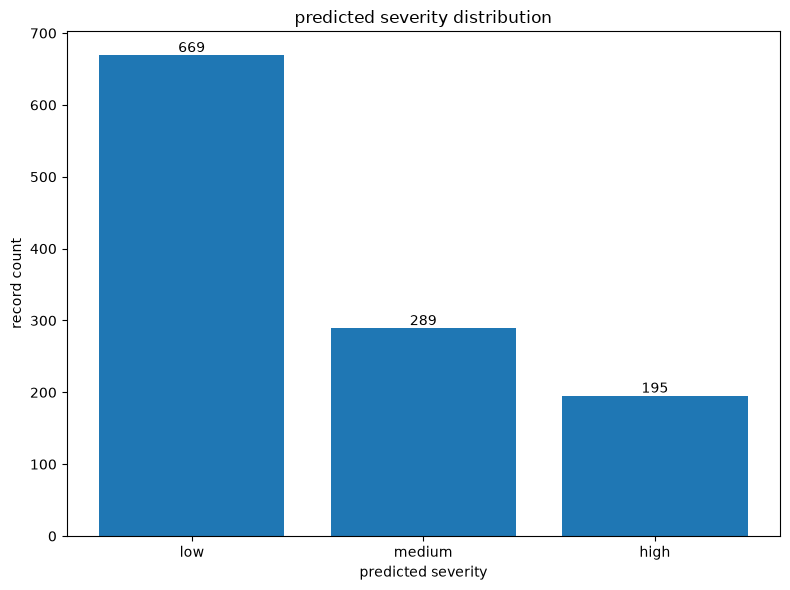

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/02_recovery_priority_distribution.png


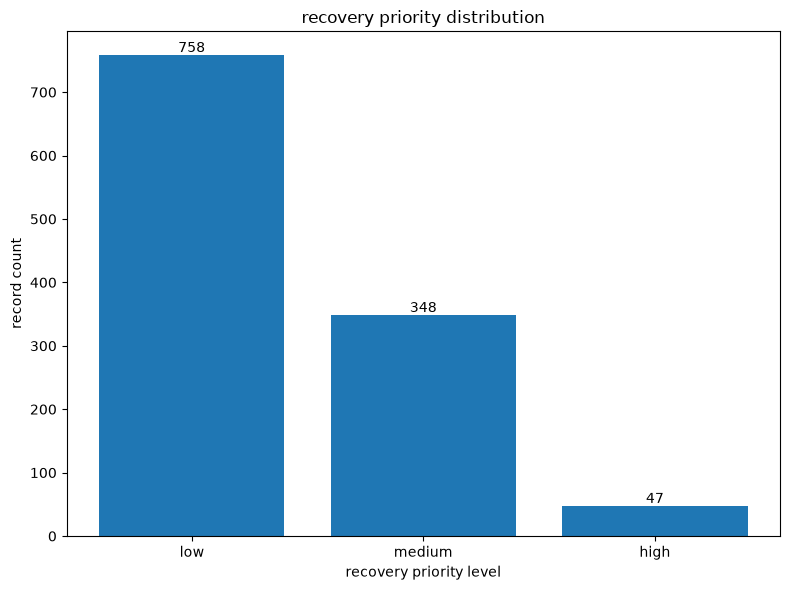

26/07/17 21:48:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/03_top_recovery_priority_routes.png


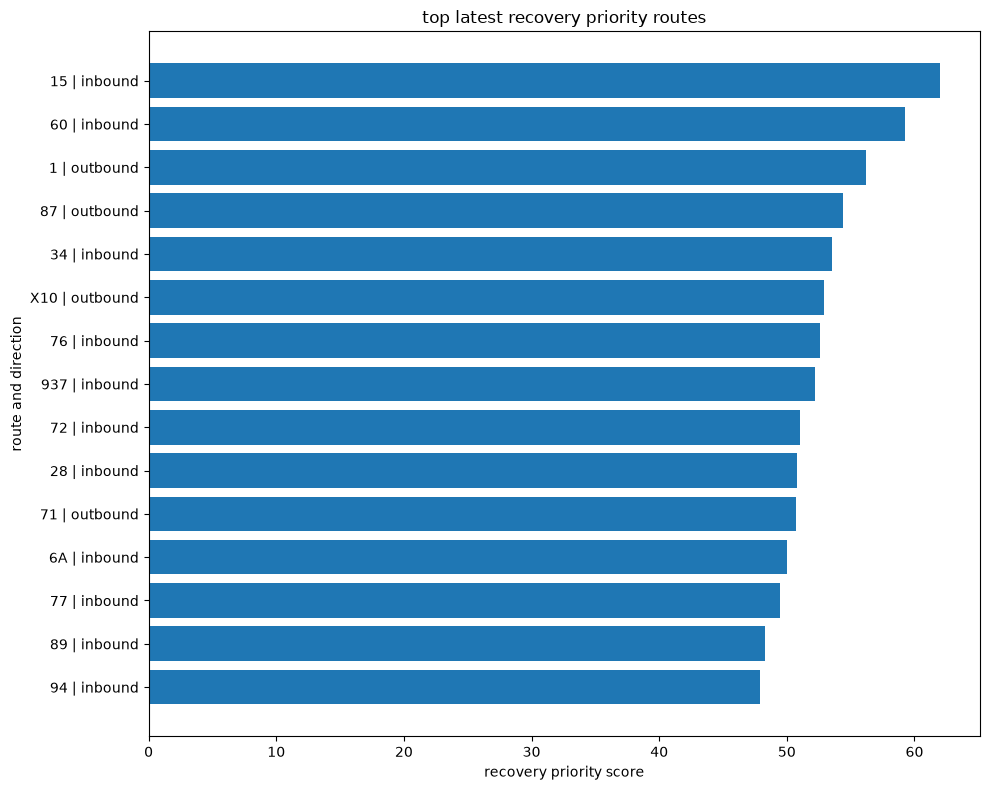

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/04_average_priority_by_hour.png


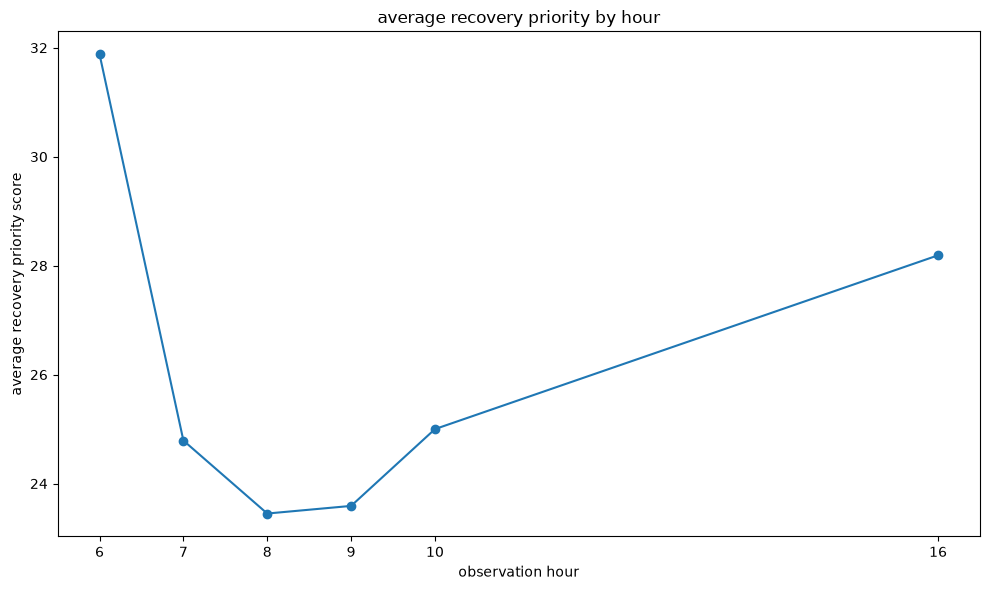

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/05_priority_by_direction.png


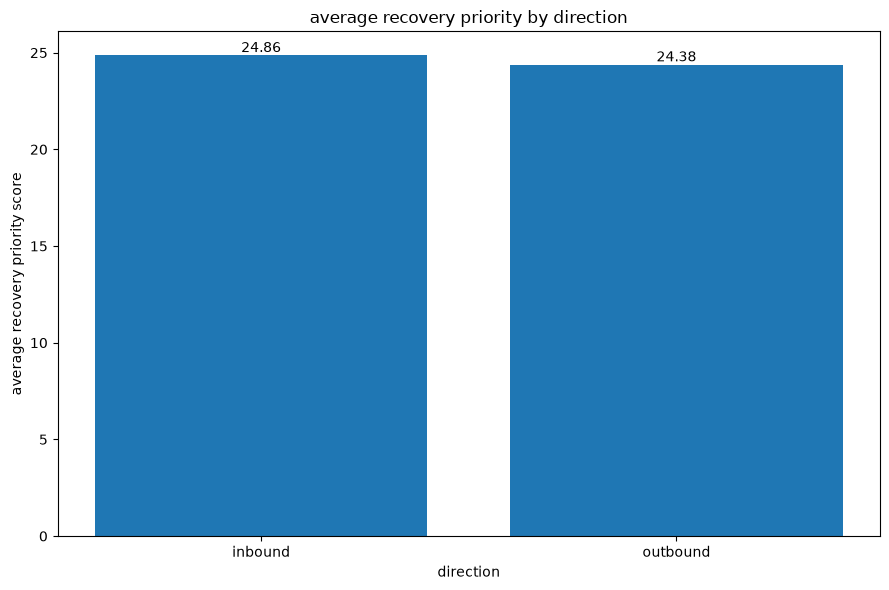

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/06_recommended_recovery_actions.png


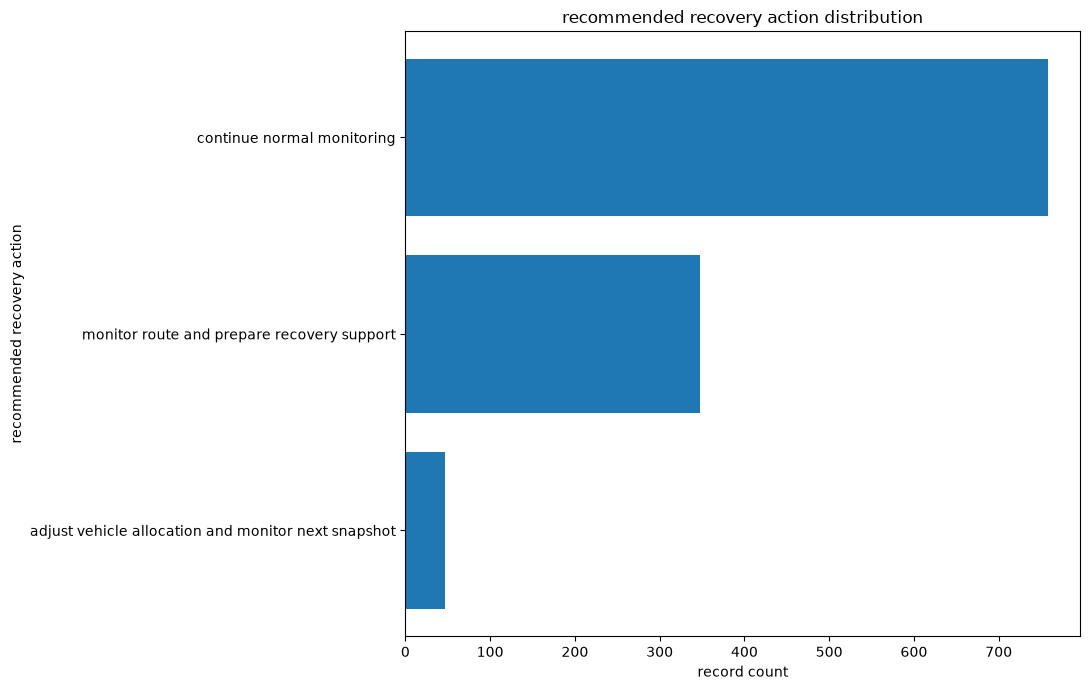

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/07_priority_by_predicted_severity.png


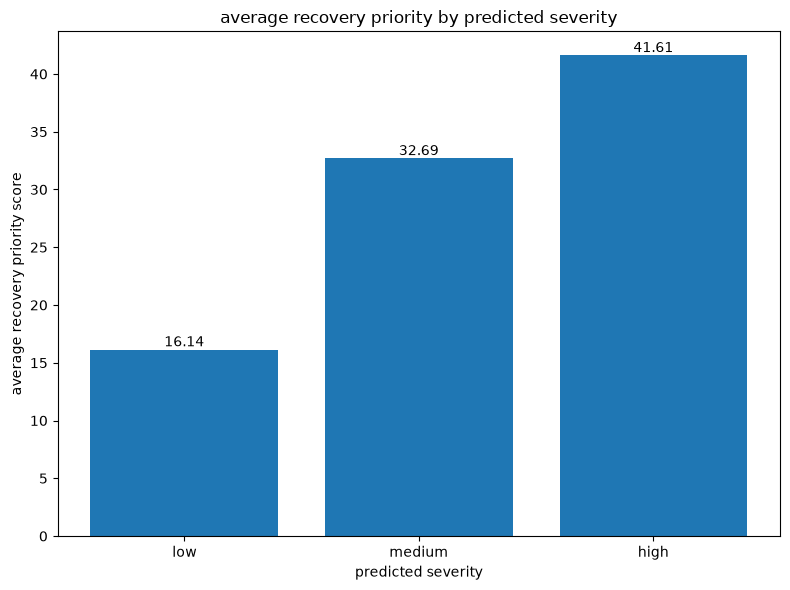

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority/08_risk_probability_and_priority_score.png


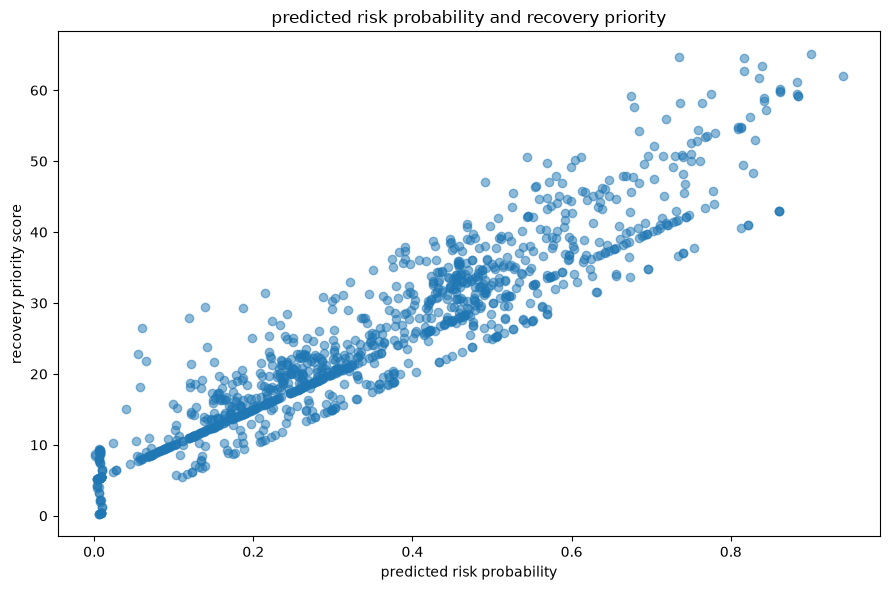

In [13]:
# prepare common category orders
severity_order = ["low","medium","high"]
priority_order_names = ["low","medium","high","critical"]
# visualization 1 predicted severity distribution
predicted_severity_pdf = priority_df.groupBy("predicted_severity").count().toPandas()
predicted_severity_pdf["predicted_severity"] = pd.Categorical(predicted_severity_pdf["predicted_severity"],categories=severity_order,ordered=True)
predicted_severity_pdf = predicted_severity_pdf.sort_values("predicted_severity")
plt.figure(figsize=(8,6))
severity_bars = plt.bar(predicted_severity_pdf["predicted_severity"],predicted_severity_pdf["count"])
plt.title("predicted severity distribution")
plt.xlabel("predicted severity")
plt.ylabel("record count")
for bar,value in zip(severity_bars,predicted_severity_pdf["count"]):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{int(value)}",ha="center",va="bottom")
plt.tight_layout()
predicted_severity_figure_path = priority_visualization_path / "01_predicted_severity_distribution.png"
plt.savefig(predicted_severity_figure_path,dpi=300,bbox_inches="tight")
print("saved:",predicted_severity_figure_path)
plt.show()
plt.close()
# visualization 2 recovery priority distribution
priority_level_pdf = priority_df.groupBy("recovery_priority_level").count().toPandas()
priority_level_pdf["recovery_priority_level"] = pd.Categorical(priority_level_pdf["recovery_priority_level"],categories=priority_order_names,ordered=True)
priority_level_pdf = priority_level_pdf.sort_values("recovery_priority_level")
plt.figure(figsize=(8,6))
priority_bars = plt.bar(priority_level_pdf["recovery_priority_level"],priority_level_pdf["count"])
plt.title("recovery priority distribution")
plt.xlabel("recovery priority level")
plt.ylabel("record count")
for bar,value in zip(priority_bars,priority_level_pdf["count"]):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{int(value)}",ha="center",va="bottom")
plt.tight_layout()
priority_distribution_figure_path = priority_visualization_path / "02_recovery_priority_distribution.png"
plt.savefig(priority_distribution_figure_path,dpi=300,bbox_inches="tight")
print("saved:",priority_distribution_figure_path)
plt.show()
plt.close()
# visualization 3 top latest recovery priority routes
top_latest_routes_pdf = (
    latest_route_ranking_df
    .select("latest_recovery_rank","line_ref","published_line_name","direction_ref","recovery_priority_score")
    .orderBy("latest_recovery_rank","line_ref")
    .limit(15)
    .toPandas()
)
top_latest_routes_pdf["route_label"] = top_latest_routes_pdf["published_line_name"].fillna(top_latest_routes_pdf["line_ref"]).astype(str) + " | " + top_latest_routes_pdf["direction_ref"].fillna("unknown").astype(str)
top_latest_routes_pdf = top_latest_routes_pdf.sort_values("recovery_priority_score",ascending=True)
plt.figure(figsize=(10,8))
plt.barh(top_latest_routes_pdf["route_label"],top_latest_routes_pdf["recovery_priority_score"])
plt.title("top latest recovery priority routes")
plt.xlabel("recovery priority score")
plt.ylabel("route and direction")
plt.tight_layout()
top_routes_figure_path = priority_visualization_path / "03_top_recovery_priority_routes.png"
plt.savefig(top_routes_figure_path,dpi=300,bbox_inches="tight")
print("saved:",top_routes_figure_path)
plt.show()
plt.close()
# visualization 4 average priority by hour
hourly_priority_pdf = priority_df.groupBy("observation_hour").agg(F.round(F.avg("recovery_priority_score"),2).alias("average_priority_score")).orderBy("observation_hour").toPandas()
plt.figure(figsize=(10,6))
plt.plot(hourly_priority_pdf["observation_hour"],hourly_priority_pdf["average_priority_score"],marker="o")
plt.title("average recovery priority by hour")
plt.xlabel("observation hour")
plt.ylabel("average recovery priority score")
plt.xticks(hourly_priority_pdf["observation_hour"])
plt.tight_layout()
hourly_priority_figure_path = priority_visualization_path / "04_average_priority_by_hour.png"
plt.savefig(hourly_priority_figure_path,dpi=300,bbox_inches="tight")
print("saved:",hourly_priority_figure_path)
plt.show()
plt.close()
# visualization 5 average priority by direction
direction_priority_pdf = priority_df.groupBy("direction_ref").agg(F.count("*").alias("record_count"),F.round(F.avg("recovery_priority_score"),2).alias("average_priority_score")).orderBy(F.desc("average_priority_score")).toPandas()
plt.figure(figsize=(9,6))
direction_bars = plt.bar(direction_priority_pdf["direction_ref"].fillna("unknown"),direction_priority_pdf["average_priority_score"])
plt.title("average recovery priority by direction")
plt.xlabel("direction")
plt.ylabel("average recovery priority score")
for bar,value in zip(direction_bars,direction_priority_pdf["average_priority_score"]):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{value:.2f}",ha="center",va="bottom")
plt.tight_layout()
direction_priority_figure_path = priority_visualization_path / "05_priority_by_direction.png"
plt.savefig(direction_priority_figure_path,dpi=300,bbox_inches="tight")
print("saved:",direction_priority_figure_path)
plt.show()
plt.close()
# visualization 6 recommended recovery action distribution
action_count_pdf = priority_df.groupBy("recommended_recovery_action").count().orderBy(F.desc("count")).toPandas()
action_count_pdf = action_count_pdf.sort_values("count",ascending=True)
plt.figure(figsize=(11,7))
plt.barh(action_count_pdf["recommended_recovery_action"],action_count_pdf["count"])
plt.title("recommended recovery action distribution")
plt.xlabel("record count")
plt.ylabel("recommended recovery action")
plt.tight_layout()
recovery_action_figure_path = priority_visualization_path / "06_recommended_recovery_actions.png"
plt.savefig(recovery_action_figure_path,dpi=300,bbox_inches="tight")
print("saved:",recovery_action_figure_path)
plt.show()
plt.close()
# visualization 7 average priority by predicted severity
severity_priority_pdf = priority_df.groupBy("predicted_severity").agg(F.count("*").alias("record_count"),F.round(F.avg("recovery_priority_score"),2).alias("average_priority_score")).toPandas()
severity_priority_pdf["predicted_severity"] = pd.Categorical(severity_priority_pdf["predicted_severity"],categories=severity_order,ordered=True)
severity_priority_pdf = severity_priority_pdf.sort_values("predicted_severity")
plt.figure(figsize=(8,6))
severity_priority_bars = plt.bar(severity_priority_pdf["predicted_severity"],severity_priority_pdf["average_priority_score"])
plt.title("average recovery priority by predicted severity")
plt.xlabel("predicted severity")
plt.ylabel("average recovery priority score")
for bar,value in zip(severity_priority_bars,severity_priority_pdf["average_priority_score"]):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{value:.2f}",ha="center",va="bottom")
plt.tight_layout()
severity_priority_figure_path = priority_visualization_path / "07_priority_by_predicted_severity.png"
plt.savefig(severity_priority_figure_path,dpi=300,bbox_inches="tight")
print("saved:",severity_priority_figure_path)
plt.show()
plt.close()
# visualization 8 predicted risk and priority score
risk_priority_pdf = priority_df.select("predicted_risk_probability","recovery_priority_score").toPandas()
plt.figure(figsize=(9,6))
plt.scatter(risk_priority_pdf["predicted_risk_probability"],risk_priority_pdf["recovery_priority_score"],alpha=0.5)
plt.title("predicted risk probability and recovery priority")
plt.xlabel("predicted risk probability")
plt.ylabel("recovery priority score")
plt.tight_layout()
risk_priority_figure_path = priority_visualization_path / "08_risk_probability_and_priority_score.png"
plt.savefig(risk_priority_figure_path,dpi=300,bbox_inches="tight")
print("saved:",risk_priority_figure_path)
plt.show()
plt.close()

In [14]:
# define recovery output paths
priority_records_parquet_path = priority_output_path / "priority_records_parquet"
priority_records_csv_path = priority_output_path / "priority_records_csv"
route_summary_csv_path = priority_output_path / "route_recovery_summary"
latest_ranking_csv_path = priority_output_path / "latest_route_recovery_ranking"
action_summary_csv_path = priority_output_path / "recovery_action_summary"
# save row level priority records as parquet
(
    priority_df
    .repartition(4,"line_ref")
    .write
    .mode("overwrite")
    .parquet(str(priority_records_parquet_path))
)
# save row level priority records as csv
(
    priority_df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv(str(priority_records_csv_path))
)
# save route recovery summary
(
    route_recovery_summary_df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv(str(route_summary_csv_path))
)
# save latest route recovery ranking
(
    latest_route_ranking_df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv(str(latest_ranking_csv_path))
)
# save recovery action summary
recovery_action_summary_df = (
    priority_df
    .groupBy(
        "recovery_priority_level",
        "recommended_recovery_action"
    )
    .agg(
        F.count("*").alias("record_count"),
        F.round(
            F.avg("recovery_priority_score"),
            2
        ).alias("average_priority_score")
    )
    .orderBy(
        F.desc("average_priority_score")
    )
)
(
    recovery_action_summary_df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv(str(action_summary_csv_path))
)
print("saved:",priority_records_parquet_path)
print("saved:",priority_records_csv_path)
print("saved:",route_summary_csv_path)
print("saved:",latest_ranking_csv_path)
print("saved:",action_summary_csv_path)

26/07/17 21:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/17 21:48:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority/priority_records_parquet
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority/priority_records_csv
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority/route_recovery_summary
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority/latest_route_recovery_ranking
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority/recovery_action_summary


In [15]:
# display spark ui address
spark_ui_url = spark.sparkContext.uiWebUrl
print("spark ui url:",spark_ui_url)

spark ui url: http://192.168.1.2:4041


In [17]:
# define required output paths
required_output_paths = [
    priority_records_parquet_path,
    priority_records_csv_path,
    route_summary_csv_path,
    latest_ranking_csv_path,
    action_summary_csv_path,
    predicted_severity_figure_path,
    priority_distribution_figure_path,
    top_routes_figure_path,
    hourly_priority_figure_path,
    direction_priority_figure_path,
    recovery_action_figure_path,
    severity_priority_figure_path,
    risk_priority_figure_path
]
# find missing outputs
missing_output_paths = [
    str(output_path)
    for output_path in required_output_paths
    if not output_path.exists()
]
print("missing output paths:",missing_output_paths)
if missing_output_paths:
    raise ValueError("some route recovery outputs are missing")
if priority_rows != prediction_rows:
    raise ValueError("priority row count does not match prediction row count")
print("route recovery priority completed successfully")
print("prediction rows processed:",f"{prediction_rows:,}")
print("priority rows created:",f"{priority_rows:,}")
print("route summaries created:",f"{route_summary_rows:,}")
print("latest route rankings created:",f"{latest_route_rows:,}")
print("outputs saved in:",priority_output_path)
print("visualizations saved in:",priority_visualization_path)


missing output paths: []
route recovery priority completed successfully
prediction rows processed: 1,153
priority rows created: 1,153
route summaries created: 244
latest route rankings created: 244
outputs saved in: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/recovery_priority
visualizations saved in: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/recovery_priority
